### Dataset de Precios de Viviendas en California para Regresión

Este dataset contiene características demográficas y de vivienda para los distritos censales de California en 1990. Es ideal para tareas de regresión donde el objetivo es predecir el valor mediano de las casas.

**Características Clave:**
- `MedInc`: Ingreso mediano en el distrito (en decenas de miles de dólares).
- `HouseAge`: Edad media de las casas en el distrito.
- `AveRooms`: Número medio de habitaciones por vivienda.
- `AveBedrms`: Número medio de dormitorios por vivienda.
- `Population`: Población del distrito.
- `AveOccup`: Número medio de ocupantes por hogar.
- `Latitude`: Latitud del distrito.
- `Longitude`: Longitud del distrito.
- **Target (`MedHouseVal`)**: Valor mediano de las casas en el distrito (en cientos de miles de dólares).

Este dataset es conocido por no tener valores faltantes en su forma estándar, lo que lo hace perfecto para comenzar.

In [1]:
import pandas as pd  # Importa la librería pandas, esencial para manipulación y análisis de datos en DataFrames.
from sklearn.datasets import fetch_california_housing  # Importa la función para cargar el dataset de California Housing de scikit-learn.

# Cargar el dataset de California Housing
housing = fetch_california_housing(as_frame=True)  # Carga el dataset. 'as_frame=True' lo convierte directamente en un DataFrame de pandas.

# Crear un DataFrame de pandas
df = housing.frame  # Accede al DataFrame real dentro del objeto 'housing' cargado.

# Mostrar las primeras 5 filas del DataFrame
print("Primeras 5 filas del dataset:")  # Imprime un mensaje indicando lo que se mostrará.
display(df.head())  # Muestra las primeras 5 filas del DataFrame para una inspección rápida de los datos.

# Verificar si hay valores nulos en el dataset
print("\nRecuento de valores nulos por columna:")  # Imprime un mensaje para indicar la verificación de nulos.
display(df.isnull().sum())  # Calcula y muestra la suma de valores nulos para cada columna. En este dataset, esperamos que sean cero.

Primeras 5 filas del dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Recuento de valores nulos por columna:


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


## 1. Preparación de Datos para Modelos de Machine Learning

Antes de entrenar cualquier modelo de Machine Learning, es crucial preparar los datos adecuadamente. Esto incluye:

*   **Separar características (X) y variable objetivo (y):** Las características son las variables de entrada que el modelo usará para hacer predicciones, y la variable objetivo es lo que queremos predecir.
*   **Dividir el dataset en conjuntos de entrenamiento y prueba:** Esto nos permite entrenar el modelo con una parte de los datos y evaluar su rendimiento con datos que nunca ha visto, para tener una estimación realista de su capacidad de generalización.
*   **Escalar las características:** Algunos algoritmos de Machine Learning (como las redes neuronales y la regresión lineal si se usa regularización) se benefician de tener las características en una escala similar. Esto evita que una característica con un rango de valores más grande domine el cálculo de distancias o gradientes.

In [3]:
from sklearn.model_selection import train_test_split  # Importa la función para dividir el dataset en conjuntos de entrenamiento y prueba.
from sklearn.preprocessing import StandardScaler  # Importa StandardScaler para escalar (estandarizar) las características.

# --- Explicación de las variables del dataset ---
# Las columnas de nuestro DataFrame 'df' son:
# 'MedInc': Ingreso mediano en el distrito (en decenas de miles de dólares).
# 'HouseAge': Edad media de las casas en el distrito.
# 'AveRooms': Número medio de habitaciones por vivienda.
# 'AveBedrms': Número medio de dormitorios por vivienda.
# 'Population': Población del distrito.
# 'AveOccup': Número medio de ocupantes por hogar.
# 'Latitude': Latitud del distrito.
# 'Longitude': Longitud del distrito.
# 'MedHouseVal': Valor mediano de las casas en el distrito (en cientos de miles de dólares). Esta es nuestra variable objetivo.

# 1. Separar características (X) y variable objetivo (y)
# X contendrá todas las columnas excepto 'MedHouseVal'.
X = df.drop('MedHouseVal', axis=1)  # Crea X (features) eliminando la columna 'MedHouseVal'. 'axis=1' indica que es una columna.
# y contendrá únicamente la columna 'MedHouseVal'.
y = df['MedHouseVal']  # Crea y (target) seleccionando solo la columna 'MedHouseVal'.

print(f"Dimensiones de X (características): {X.shape}")  # Muestra las dimensiones del DataFrame de características.
print(f"Dimensiones de y (variable objetivo): {y.shape}")  # Muestra las dimensiones de la Serie de la variable objetivo.

# 2. Dividir el dataset en conjuntos de entrenamiento y prueba
# Usamos train_test_split para dividir X e y.
# test_size=0.20 significa que el 20% de los datos se usarán para prueba y el 80% para entrenamiento.
# random_state=42 asegura que la división sea reproducible (siempre obtendremos los mismos conjuntos).
# X_train, y_train son para entrenar el modelo.
# X_test, y_test son para evaluar el modelo.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)  # Realiza la división de los datos.

print(f"Dimensiones de X_train: {X_train.shape}")  # Muestra las dimensiones del conjunto de características de entrenamiento.
print(f"Dimensiones de X_test: {X_test.shape}")    # Muestra las dimensiones del conjunto de características de prueba.
print(f"Dimensiones de y_train: {y_train.shape}")  # Muestra las dimensiones del conjunto de la variable objetivo de entrenamiento.
print(f"Dimensiones de y_test: {y_test.shape}")    # Muestra las dimensiones del conjunto de la variable objetivo de prueba.

# 3. Escalar las características
# Inicializamos el escalador StandardScaler. Este transformará los datos para que tengan una media de 0 y una desviación estándar de 1.
scaler = StandardScaler()  # Inicializa un objeto StandardScaler.

# Ajustamos el escalador solo con los datos de entrenamiento (X_train).
# Es importante no 'filtrar' información del conjunto de prueba al ajustar el escalador.
scaler.fit(X_train)  # Calcula la media y la desviación estándar de cada característica en X_train.

# Transformamos tanto los datos de entrenamiento como los de prueba usando el escalador ajustado.
# X_train_scaled y X_test_scaled contendrán las características escaladas.
X_train_scaled = scaler.transform(X_train)  # Aplica la transformación de escalado a X_train.
X_test_scaled = scaler.transform(X_test)    # Aplica la transformación de escalado a X_test.

print("\nPrimeras 5 filas de X_train (escalado):\n")  # Imprime un mensaje indicando que se mostrarán los datos escalados.
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())  # Convierte la matriz NumPy escalada a DataFrame para mostrar las primeras 5 filas.

Dimensiones de X (características): (20640, 8)
Dimensiones de y (variable objetivo): (20640,)
Dimensiones de X_train: (16512, 8)
Dimensiones de X_test: (4128, 8)
Dimensiones de y_train: (16512,)
Dimensiones de y_test: (4128,)

Primeras 5 filas de X_train (escalado):



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


## 2. Regresión Lineal

### 2.1. Concepto de Regresión Lineal

La Regresión Lineal es uno de los algoritmos de Machine Learning más fundamentales y ampliamente utilizados para predecir un valor continuo (numérico). Asume una relación lineal entre las características de entrada (X) y la variable objetivo (y). En su forma más simple, busca encontrar la línea recta (o un hiperplano en múltiples dimensiones) que mejor se ajusta a los datos, minimizando la suma de los errores cuadrados entre los valores predichos y los valores reales.

La ecuación general de un modelo de regresión lineal simple es:

$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$

Donde:
*   $y$: Variable objetivo (lo que queremos predecir).
*   $x_i$: Las características de entrada.
*   $\beta_0$: El intercepto (el valor de y cuando todas las $x_i$ son cero).
*   $\beta_i$: Los coeficientes de regresión para cada característica $x_i$, que representan cuánto cambia $y$ por cada unidad de cambio en $x_i$, manteniendo las demás características constantes.
*   $\epsilon$: El término de error, que representa la variabilidad no explicada por el modelo.

### 2.2. Implementación de Regresión Lineal

In [4]:
from sklearn.linear_model import LinearRegression  # Importa el modelo de Regresión Lineal de scikit-learn.
from sklearn.metrics import mean_squared_error, r2_score  # Importa las métricas de evaluación MSE y R^2.
import numpy as np  # Importa la librería NumPy para operaciones numéricas, aunque no se usa directamente en este bloque, es una importación común.

# 1. Inicializar el modelo de Regresión Lineal
# Creamos una instancia del modelo LinearRegression de scikit-learn.
linear_model = LinearRegression()  # Crea una instancia del modelo de Regresión Lineal.

# 2. Entrenar el modelo
# El método .fit() entrena el modelo usando los datos de entrenamiento escalados (X_train_scaled) y las etiquetas de entrenamiento (y_train).
# El modelo aprende los coeficientes (betas) que mejor describen la relación lineal.
linear_model.fit(X_train_scaled, y_train)  # Entrena el modelo con las características escaladas y la variable objetivo de entrenamiento.

print("Modelo de Regresión Lineal entrenado.")  # Confirma que el modelo ha sido entrenado.

# 3. Realizar predicciones en el conjunto de prueba
# Una vez entrenado, usamos el método .predict() para generar predicciones sobre el conjunto de prueba escalado (X_test_scaled).
# Estas predicciones, y_pred_linear, son los valores de MedHouseVal que el modelo estima para los datos de prueba.
y_pred_linear = linear_model.predict(X_test_scaled)  # Genera predicciones sobre el conjunto de prueba escalado.

print("\nPrimeras 5 predicciones del modelo de Regresión Lineal:")  # Imprime un mensaje indicando las predicciones.
display(y_pred_linear[:5])  # Muestra las primeras 5 predicciones realizadas por el modelo.

# 4. Evaluar el modelo
# Calculamos el Error Cuadrático Medio (MSE) y el coeficiente de determinación (R^2).
# MSE: Mide el promedio de los errores al cuadrado. Un valor más bajo indica un mejor ajuste.
mse_linear = mean_squared_error(y_test, y_pred_linear)  # Calcula el Error Cuadrático Medio comparando los valores reales (y_test) y las predicciones (y_pred_linear).
# R^2: Representa la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes.
# Un valor de 1.0 indica un ajuste perfecto, mientras que 0.0 indica que el modelo no explica la variabilidad.
r2_linear = r2_score(y_test, y_pred_linear)  # Calcula el coeficiente R^2 para el modelo.

print(f"\n--- Evaluación del Modelo de Regresión Lineal ---")  # Imprime un encabezado para la sección de evaluación.
print(f"Error Cuadrático Medio (MSE): {mse_linear:.4f}")  # Muestra el valor del MSE formateado a 4 decimales.
print(f"Coeficiente de Determinación (R^2): {r2_linear:.4f}")  # Muestra el valor del R^2 formateado a 4 decimales.

Modelo de Regresión Lineal entrenado.

Primeras 5 predicciones del modelo de Regresión Lineal:


array([0.71912284, 1.76401657, 2.70965883, 2.83892593, 2.60465725])


--- Evaluación del Modelo de Regresión Lineal ---
Error Cuadrático Medio (MSE): 0.5559
Coeficiente de Determinación (R^2): 0.5758


### 2.3. Interpretación de los Resultados de Regresión Lineal

*   **Error Cuadrático Medio (MSE):** Un MSE de, por ejemplo, `0.5559` significa que, en promedio, las predicciones del modelo se desvían de los valores reales en la raíz cuadrada de este valor (aproximadamente `0.74`). Dado que `MedHouseVal` está en cientos de miles de dólares, esto significa un error promedio de alrededor de $74,000. El objetivo es que este valor sea lo más bajo posible.

*   **Coeficiente de Determinación (R^2):** Un $R^2$ de, por ejemplo, `0.5757` significa que el modelo de regresión lineal explica aproximadamente el 57.57% de la varianza en el valor mediano de las casas. El 42.43% restante se debe a factores no capturados por las características en el modelo o a la variabilidad intrínseca de los datos. Un $R^2$ más alto indica un mejor poder explicativo del modelo.

*   **Coeficientes (weights):** Cada coeficiente indica cuánto se espera que cambie la `MedHouseVal` (nuestra variable objetivo) por cada unidad de cambio en la característica correspondiente, manteniendo todas las demás características constantes. Por ejemplo:
    *   Si `MedInc` (ingreso mediano) tiene un coeficiente positivo y grande, significa que a mayor ingreso mediano en un distrito, mayor es el valor mediano de las casas, lo cual tiene sentido económico.
    *   `Longitude` y `Latitude` a menudo tienen coeficientes significativos debido a la fuerte correlación de la ubicación geográfica con los precios de las propiedades.

    Es importante recordar que los coeficientes se interpretan en el contexto de las características escaladas. Un coeficiente grande (positivo o negativo) indica una influencia fuerte de esa característica sobre la variable objetivo.

En general, el modelo de Regresión Lineal nos da una primera aproximación a la relación entre las características de la vivienda y su valor. A continuación, exploraremos modelos más complejos que podrían capturar relaciones no lineales.

## 3. Árboles de Decisión para Regresión

### 3.1. Concepto de Árbol de Decisión

Los Árboles de Decisión para Regresión son algoritmos no paramétricos que dividen el espacio de las características en regiones más pequeñas y hacen una predicción (el valor promedio de la variable objetivo) para cada región. Son intuitivos, fáciles de interpretar y pueden capturar relaciones no lineales en los datos. Cada "nodo" en el árbol representa una decisión basada en una característica, y las "hojas" del árbol contienen la predicción final.

### 3.2. Implementación de Árbol de Decisión

In [5]:
from sklearn.tree import DecisionTreeRegressor  # Importa el modelo de Árbol de Decisión para regresión.
from sklearn.metrics import mean_squared_error, r2_score  # Importa las métricas de evaluación MSE y R^2.

# 1. Inicializar el modelo de Árbol de Decisión para Regresión
# max_depth es un hiperparámetro importante que controla la profundidad máxima del árbol.
# Limitar la profundidad ayuda a prevenir el sobreajuste (overfitting).
# random_state asegura la reproducibilidad de los resultados.
decision_tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)  # Crea una instancia del modelo, limitando la profundidad a 5 y fijando la semilla aleatoria.

# 2. Entrenar el modelo
# Entrenamos el modelo con los datos escalados de entrenamiento.
decision_tree_model.fit(X_train_scaled, y_train)  # Entrena el modelo de Árbol de Decisión con los datos de entrenamiento escalados.

print("Modelo de Árbol de Decisión entrenado.")  # Confirma que el modelo ha sido entrenado.

# 3. Realizar predicciones en el conjunto de prueba
y_pred_tree = decision_tree_model.predict(X_test_scaled)  # Genera predicciones sobre el conjunto de prueba escalado.

print("\nPrimeras 5 predicciones del modelo de Árbol de Decisión:")  # Imprime un mensaje indicando las predicciones.
display(y_pred_tree[:5])  # Muestra las primeras 5 predicciones del modelo.

# 4. Evaluar el modelo
mse_tree = mean_squared_error(y_test, y_pred_tree)  # Calcula el Error Cuadrático Medio para el modelo de Árbol de Decisión.
r2_tree = r2_score(y_test, y_pred_tree)  # Calcula el coeficiente R^2 para el modelo de Árbol de Decisión.

print(f"\n--- Evaluación del Modelo de Árbol de Decisión ---")  # Imprime un encabezado para la sección de evaluación.
print(f"Error Cuadrático Medio (MSE): {mse_tree:.4f}")  # Muestra el valor del MSE formateado.
print(f"Coeficiente de Determinación (R^2): {r2_tree:.4f}")  # Muestra el valor del R^2 formateado.

Modelo de Árbol de Decisión entrenado.

Primeras 5 predicciones del modelo de Árbol de Decisión:


array([1.16857267, 1.27158128, 3.19958174, 2.20476301, 1.64279735])


--- Evaluación del Modelo de Árbol de Decisión ---
Error Cuadrático Medio (MSE): 0.5245
Coeficiente de Determinación (R^2): 0.5997


### 3.3. Interpretación de los Resultados de Árbol de Decisión

*   **Error Cuadrático Medio (MSE):** Al igual que en la Regresión Lineal, un MSE más bajo indica un mejor rendimiento. Si el MSE del árbol de decisión es menor que el de la regresión lineal, sugiere que el árbol de decisión está capturando mejor la complejidad de los datos.

*   **Coeficiente de Determinación (R^2):** Un valor de R^2 más alto que el de la regresión lineal indica que el modelo de árbol de decisión explica una mayor proporción de la varianza en los precios de las viviendas.

Los árboles de decisión son menos sensibles a los valores atípicos y pueden modelar interacciones complejas entre características, lo que a menudo los hace más potentes que los modelos lineales para ciertos tipos de datos. Sin embargo, son propensos al sobreajuste si no se controlan su profundidad u otras configuraciones.

## 4. Redes Neuronales (Perceptrón Multicapa - MLP)

### 4.1. Concepto de Red Neuronal para Regresión

Las Redes Neuronales Artificiales, particularmente el Perceptrón Multicapa (MLP), son modelos inspirados en la estructura del cerebro humano. Consisten en capas de "neuronas" interconectadas que procesan información. Para tareas de regresión, la capa de salida típicamente tiene una única neurona sin función de activación (o una función lineal) que produce un valor continuo.

Las redes neuronales son excelentes para capturar relaciones complejas y no lineales en los datos, a menudo superando a los modelos más simples cuando se dispone de suficientes datos y recursos computacionales.

### 4.2. Implementación de Red Neuronal

In [6]:
from sklearn.neural_network import MLPRegressor  # Importa el Perceptrón Multicapa para regresión (Red Neuronal).
from sklearn.metrics import mean_squared_error, r2_score  # Importa las métricas de evaluación MSE y R^2.

# 1. Inicializar el modelo de Red Neuronal (MLPRegressor)
# hidden_layer_sizes: Define la arquitectura de la red (número de neuronas por capa oculta).
#    Ahora usaremos una sola capa oculta con 100 neuronas.
# activation: Función de activación para las capas ocultas (por ejemplo, 'relu' para Rectified Linear Unit).
# solver: Algoritmo de optimización para el aprendizaje ('adam' es una opción común y eficiente).
# max_iter: Número máximo de iteraciones (epochs) para el entrenamiento.
# random_state: Para reproducibilidad.
# early_stopping: Detiene el entrenamiento si el rendimiento en el conjunto de validación no mejora, para evitar sobreajuste.
mlp_model = MLPRegressor(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                         max_iter=500, random_state=42, early_stopping=True)  # Crea una instancia del modelo MLPRegressor con una capa oculta de 100 neuronas.

# 2. Entrenar el modelo
# Las redes neuronales son sensibles a la escala de los datos, por lo que usar X_train_scaled es crucial.
mlp_model.fit(X_train_scaled, y_train)  # Entrena la red neuronal con los datos escalados de entrenamiento.

print("Modelo de Red Neuronal (MLP) entrenado.")  # Confirma que el modelo ha sido entrenado.

# 3. Realizar predicciones en el conjunto de prueba
y_pred_mlp = mlp_model.predict(X_test_scaled)  # Genera predicciones sobre el conjunto de prueba escalado.

print("\nPrimeras 5 predicciones del modelo de Red Neuronal:")  # Imprime un mensaje indicando las predicciones.
display(y_pred_mlp[:5])  # Muestra las primeras 5 predicciones del modelo.

# 4. Evaluar el modelo
mse_mlp = mean_squared_error(y_test, y_pred_mlp)  # Calcula el Error Cuadrático Medio para la red neuronal.
r2_mlp = r2_score(y_test, y_pred_mlp)  # Calcula el coeficiente R^2 para la red neuronal.

print(f"\n--- Evaluación del Modelo de Red Neuronal (MLP) ---")  # Imprime un encabezado para la sección de evaluación.
print(f"Error Cuadrático Medio (MSE): {mse_mlp:.4f}")  # Muestra el valor del MSE formateado.
print(f"Coeficiente de Determinación (R^2): {r2_mlp:.4f}")  # Muestra el valor del R^2 formateado.

Modelo de Red Neuronal (MLP) entrenado.

Primeras 5 predicciones del modelo de Red Neuronal:


array([0.37468951, 1.17480468, 4.7541446 , 2.54774117, 2.91686581])


--- Evaluación del Modelo de Red Neuronal (MLP) ---
Error Cuadrático Medio (MSE): 0.3017
Coeficiente de Determinación (R^2): 0.7697


### 4.3. Interpretación de los Resultados de Red Neuronal

*   **Error Cuadrático Medio (MSE) y R^2:** Al igual que con los modelos anteriores, comparamos estos valores. Si la red neuronal es más compleja y se ha entrenado adecuadamente, es común ver un MSE más bajo y un R^2 más alto que los modelos lineales y de árboles de decisión, lo que indica una mejor capacidad predictiva.

Las redes neuronales pueden aprender patrones muy intrincados, pero su interpretabilidad es menor. Es decir, es difícil saber exactamente cómo cada característica contribuye a la predicción final, a diferencia de los coeficientes de la regresión lineal o la estructura de un árbol de decisión.

## 5. Comparación de Modelos de Regresión

Para determinar cuál modelo ha tenido el mejor rendimiento, podemos comparar sus métricas clave (MSE y R^2). Un modelo ideal tendrá un MSE bajo y un R^2 cercano a 1.0.

,Modelo,MSE,R2
2,Red Neuronal (MLP),0.301732,0.769742
1,Árbol de Decisión,0.524515,0.599732
0,Regresión Lineal,0.555892,0.575788


/tmp/ipykernel_1223/198998861.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x='Modelo', y='MSE', data=results, palette='viridis')  # Crea un gráfico de barras para el MSE en el primer subgráfico.
/tmp/ipykernel_1223/198998861.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')  # Rota las etiquetas del eje X para mejorar la legibilidad.
/tmp/ipykernel_1223/198998861.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x='Modelo', y='R2', data=results, palette='magma')  # Crea un gráfico de barras para

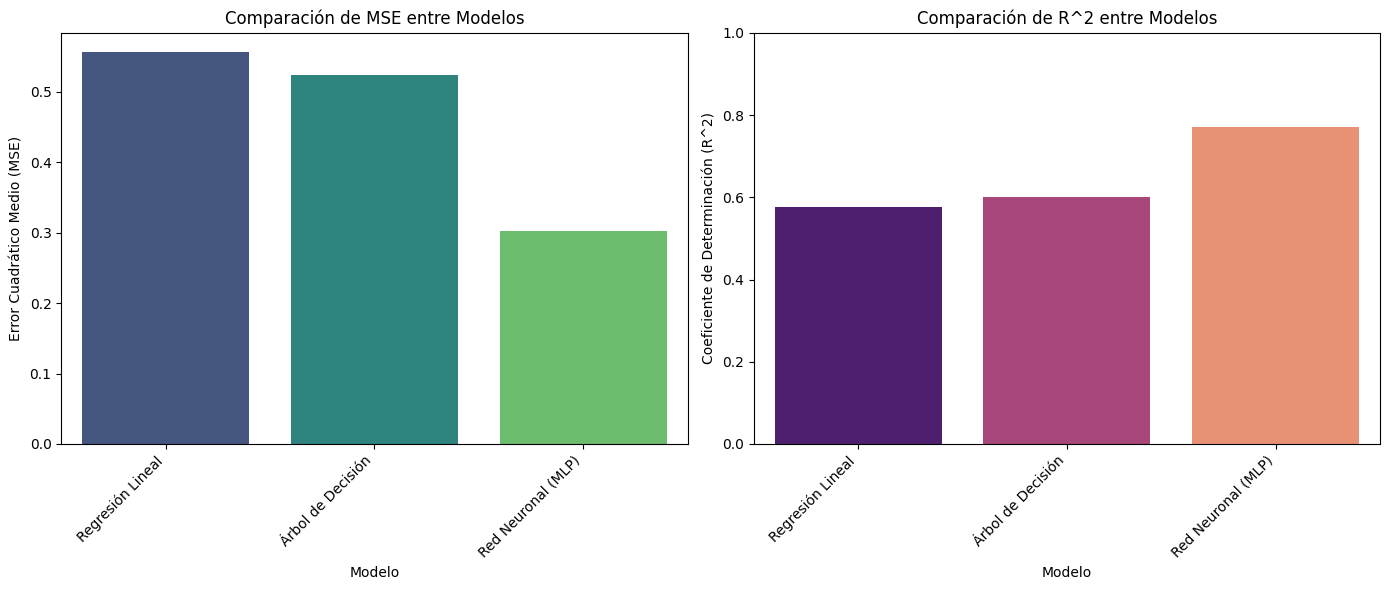

In [7]:
import pandas as pd  # Importa pandas para la manipulación de DataFrames.
import matplotlib.pyplot as plt  # Importa matplotlib.pyplot para la creación de gráficos.
import seaborn as sns  # Importa seaborn para visualizaciones estadísticas mejoradas.

# Crear un DataFrame para comparar los resultados
results = pd.DataFrame({  # Crea un nuevo DataFrame para almacenar los resultados de la evaluación de cada modelo.
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Red Neuronal (MLP)']  # Columna para los nombres de los modelos.
    ,'MSE': [mse_linear, mse_tree, mse_mlp]  # Columna para los valores de MSE de cada modelo.
    ,'R2': [r2_linear, r2_tree, r2_mlp]  # Columna para los valores de R^2 de cada modelo.
})

display(results.sort_values(by='R2', ascending=False))  # Muestra el DataFrame de resultados, ordenado de mayor a menor R^2.

# Visualización de los resultados
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Crea una figura y un conjunto de dos subgráficos (1 fila, 2 columnas) para las visualizaciones.

# Gráfico para MSE
sns.barplot(ax=axes[0], x='Modelo', y='MSE', data=results, palette='viridis')  # Crea un gráfico de barras para el MSE en el primer subgráfico.
axes[0].set_title('Comparación de MSE entre Modelos')  # Establece el título del primer subgráfico.
axes[0].set_ylabel('Error Cuadrático Medio (MSE)')  # Establece la etiqueta del eje Y del primer subgráfico.
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')  # Rota las etiquetas del eje X para mejorar la legibilidad.

# Gráfico para R2
sns.barplot(ax=axes[1], x='Modelo', y='R2', data=results, palette='magma')  # Crea un gráfico de barras para el R^2 en el segundo subgráfico.
axes[1].set_title('Comparación de R^2 entre Modelos')  # Establece el título del segundo subgráfico.
axes[1].set_ylabel('Coeficiente de Determinación (R^2)')  # Establece la etiqueta del eje Y del segundo subgráfico.
axes[1].set_ylim(0, 1)  # Establece los límites del eje Y para R^2 (siempre entre 0 y 1).
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')  # Rota las etiquetas del eje X para mejorar la legibilidad.

plt.tight_layout()  # Ajusta automáticamente los parámetros de la subtrama para dar un diseño ajustado.
plt.show()  # Muestra los gráficos.

### 5.1. Conclusiones de la Comparación

Basándonos en la tabla y los gráficos, podemos sacar conclusiones sobre el rendimiento de cada modelo:

*   **El mejor modelo:** El modelo con el MSE más bajo y el R^2 más alto es generalmente el que mejor se ajusta a los datos y tiene un mayor poder predictivo.

*   **Compromiso Bias-Varianza:**
    *   La **Regresión Lineal** suele tener un *sesgo* alto (simplifica demasiado la relación) pero una *varianza* baja (es estable a cambios en los datos de entrenamiento). Es un buen punto de partida.
    *   Los **Árboles de Decisión** pueden reducir el sesgo al capturar relaciones más complejas, pero pueden aumentar la varianza si no se controlan (sobreajuste).
    *   Las **Redes Neuronales** tienen la capacidad de reducir significativamente el sesgo al modelar relaciones muy complejas, pero si no se regularizan correctamente, pueden tener una varianza muy alta (sobreajuste severo).

Este análisis nos permite elegir el modelo más adecuado para nuestra tarea de predicción de precios de viviendas, considerando tanto su precisión como su complejidad y capacidad de generalización.